In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [ ]:
df= pd.read_csv("/content/breast-cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df_processed = df.drop('id', axis=1)
X = df_processed.drop('diagnosis', axis=1)  # Features
y = df_processed['diagnosis']               # Target

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFirst 5 rows of features (X):\n", X.head())
print("\nFirst 5 rows of target (y):\n", y.head())

Shape of features (X): (569, 30)
Shape of target (y): (569,)

First 5 rows of features (X):
    radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   


In [ ]:
y

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


In [ ]:
diagnosis_map = {'M': 1, 'B': 0}
y_mapped = y.map(diagnosis_map)

print("Original target (first 5 values):\n", y.head())
print("\nMapped target (first 5 values):\n", y_mapped.head())
print("\nValue counts of mapped target:\n", y_mapped.value_counts())

Original target (first 5 values):
 0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

Mapped target (first 5 values):
 0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

Value counts of mapped target:
 diagnosis
0    357
1    212
Name: count, dtype: int64


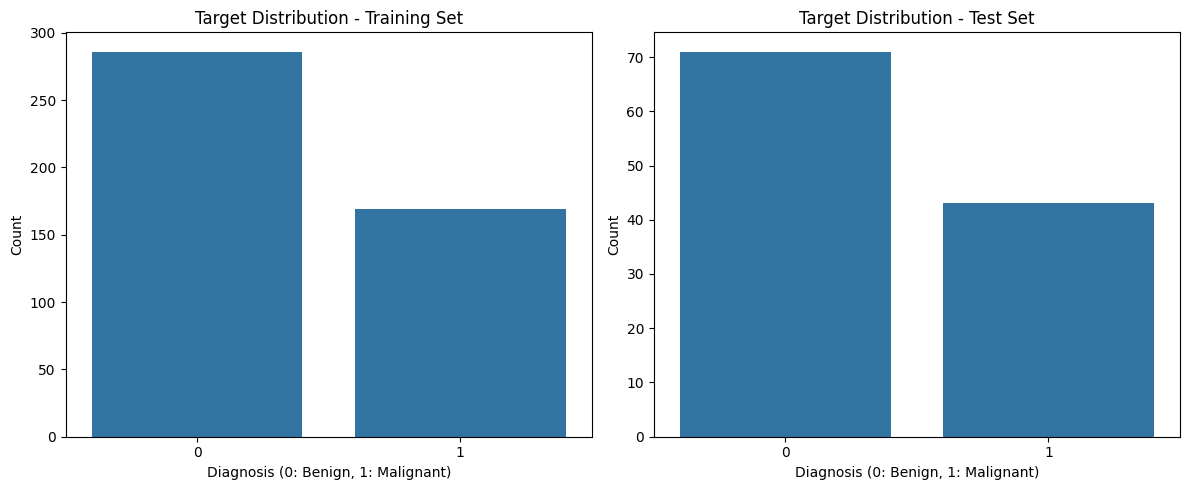

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Target Distribution - Training Set')
plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title('Target Distribution - Test Set')
plt.xlabel('Diagnosis (0: Benign, 1: Malignant)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
y_mapped


,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


In [ ]:
from sklearn.model_selection import train_test_split

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames (optional, but good for inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("First 5 rows of X_train_scaled:\n", X_train_scaled.head())
print("\nFirst 5 rows of X_test_scaled:\n", X_test_scaled.head())

First 5 rows of X_train_scaled:
    radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     0.065527      0.257694        0.077323   0.034369         0.487226   
1     0.656203      0.570172        0.674207   0.489402         0.554934   
2     0.072579      0.140345        0.080239   0.038831         0.221901   
3     0.144914      0.524518        0.142908   0.075774         0.396678   
4     0.121407      0.174839        0.118296   0.060714         0.548614   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          0.417506        0.733365             0.217445       0.504004   
1          0.903431        0.582709             0.743539       0.655633   
2          0.233306        0.140300             0.108350       0.626802   
3          0.181357        0.055740             0.080268       0.389749   
4          0.209677        0.025398             0.064115       0.841431   

   fractal_dimension_mean  ...  radius_worst  texture_worst

In [ ]:
from sklearn.linear_model import LogisticRegression
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Fit the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)


LogisticRegression(random_state=42)

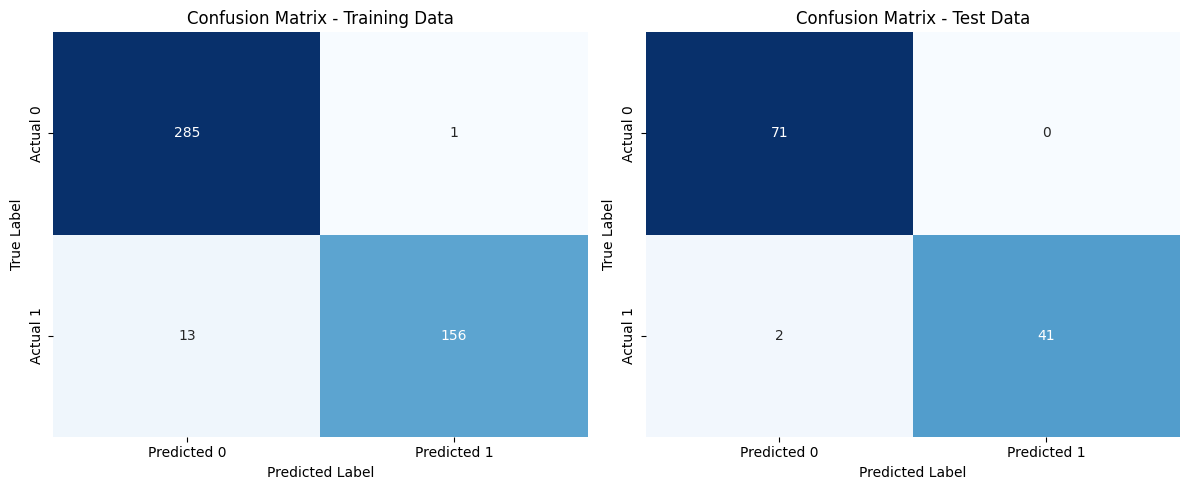

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on training data
y_train_pred = log_reg_model.predict(X_train_scaled)

# Confusion Matrix for Training Data
cm_train = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Training Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Predictions on test data (y_pred is already available from previous step)
cm_test = confusion_matrix(y_test, y_pred)

plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Classification Report for Training Data
print("\nClassification Report - Training Data:")
print(classification_report(y_train, y_train_pred))

# Classification Report for Test Data
print("\nClassification Report - Test Data:")
print(classification_report(y_test, y_pred))


Classification Report - Training Data:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       286
           1       0.99      0.92      0.96       169

    accuracy                           0.97       455
   macro avg       0.98      0.96      0.97       455
weighted avg       0.97      0.97      0.97       455


Classification Report - Test Data:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

